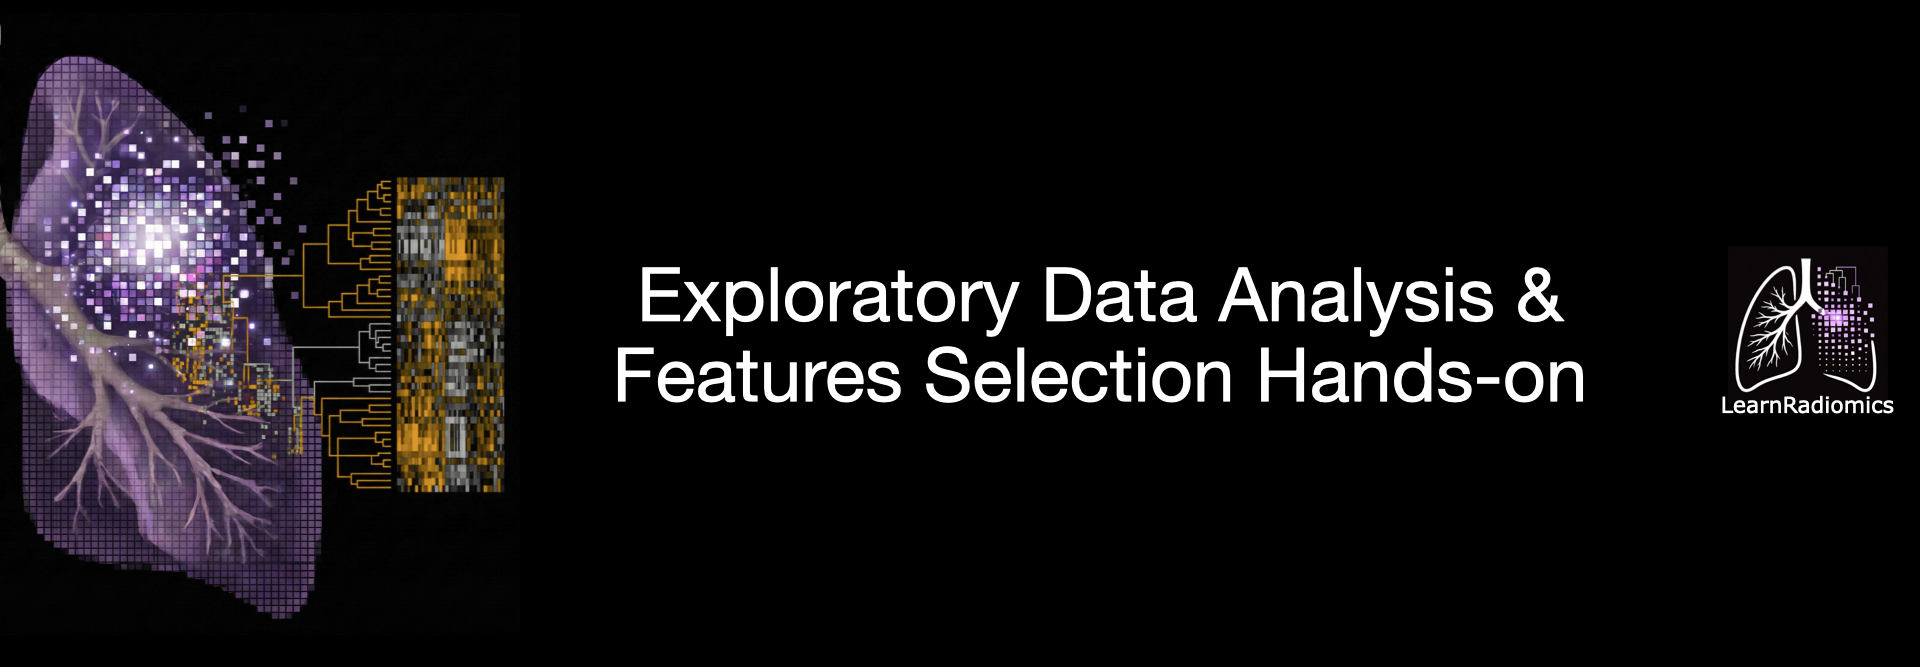

In [1]:
## General libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from collections import Counter

## Data visualization
from plotnine import *
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

## Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV, LogisticRegressionCV

import sys
sys.modules['sklearn.externals.joblib'] = joblib

## Statistical tools libraries
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro
import sklearn.metrics as mt
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
import statsmodels.api as sm
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from scipy.stats import chi2_contingency
import itertools

## Medición de timpo y flujo de trabajo
import time
from tqdm import trange

## Sistema
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

from IPython.display import clear_output

## Exploratory analysis

* NSCLC dataset with radiomic features extracted using filters.
* Target: prediction of EGFR mutation

In [2]:
url = 'https://raw.githubusercontent.com/learnradiomics/data_wrangling/main/data_radiomics_selected.xlsx'

df = pd.read_excel(url)

print(f'Number of patients: {df.shape[0]}')
print(f'Number of variables: {df.shape[1]}')

Number of patients: 161
Number of variables: 95


In [3]:
## Included clinical features
df.columns[0:13]

Index(['Gender_Female', 'Ethnicity_Caucasian',
       'Ethnicity_Native_Hawaiian/Pacific_Islander',
       'Ethnicity_African_American', 'Ethnicity_Asian',
       'Ethnicity_Hispanic/Latino', 'Smoking_status_Nonsmoker',
       'Histology_Adenocarcinoma', 'Histology_Squamous_cell_carcinoma',
       'Histology_NSCLC_NOS_(not_otherwise_specified)',
       'EGFR_mutation_status_Mutant', 'Age_at_Histological_Diagnosis',
       'Weight_(lbs)'],
      dtype='object')

In [4]:
for i in range(len(df.columns)):
    print(i, ':', df.columns[i])

0 : Gender_Female
1 : Ethnicity_Caucasian
2 : Ethnicity_Native_Hawaiian/Pacific_Islander
3 : Ethnicity_African_American
4 : Ethnicity_Asian
5 : Ethnicity_Hispanic/Latino
6 : Smoking_status_Nonsmoker
7 : Histology_Adenocarcinoma
8 : Histology_Squamous_cell_carcinoma
9 : Histology_NSCLC_NOS_(not_otherwise_specified)
10 : EGFR_mutation_status_Mutant
11 : Age_at_Histological_Diagnosis
12 : Weight_(lbs)
13 : original_glcm_MCC
14 : original_glcm_JointAverage
15 : original_glrlm_GrayLevelNonUniformityNormalized
16 : original_glrlm_GrayLevelVariance
17 : original_glrlm_HighGrayLevelRunEmphasis
18 : original_glrlm_LowGrayLevelRunEmphasis
19 : original_glszm_GrayLevelNonUniformityNormalized
20 : original_glszm_GrayLevelVariance
21 : original_glszm_HighGrayLevelZoneEmphasis
22 : original_glszm_LowGrayLevelZoneEmphasis
23 : original_gldm_GrayLevelVariance
24 : original_gldm_HighGrayLevelEmphasis
25 : original_gldm_LowGrayLevelEmphasis
26 : original_glcm_SumAverage
27 : original_glcm_Autocorrelatio

In [5]:
## Gender
print("Percentage of women:",
      Counter(df['Gender_Female'])[1]/(Counter(df['Gender_Female'])[0] + Counter(df['Gender_Female'])[1]))

Percentage of women: 0.36024844720496896


In [6]:
### Age
print(f"Mean age: {df['Age_at_Histological_Diagnosis'].mean()}")
print(f"Median age: {df['Age_at_Histological_Diagnosis'].median()}")
print(f"Age range: ({df['Age_at_Histological_Diagnosis'].min()} - {df['Age_at_Histological_Diagnosis'].max()})")

Mean age: 68.09937888198758
Median age: 68.0
Age range: (24 - 87)


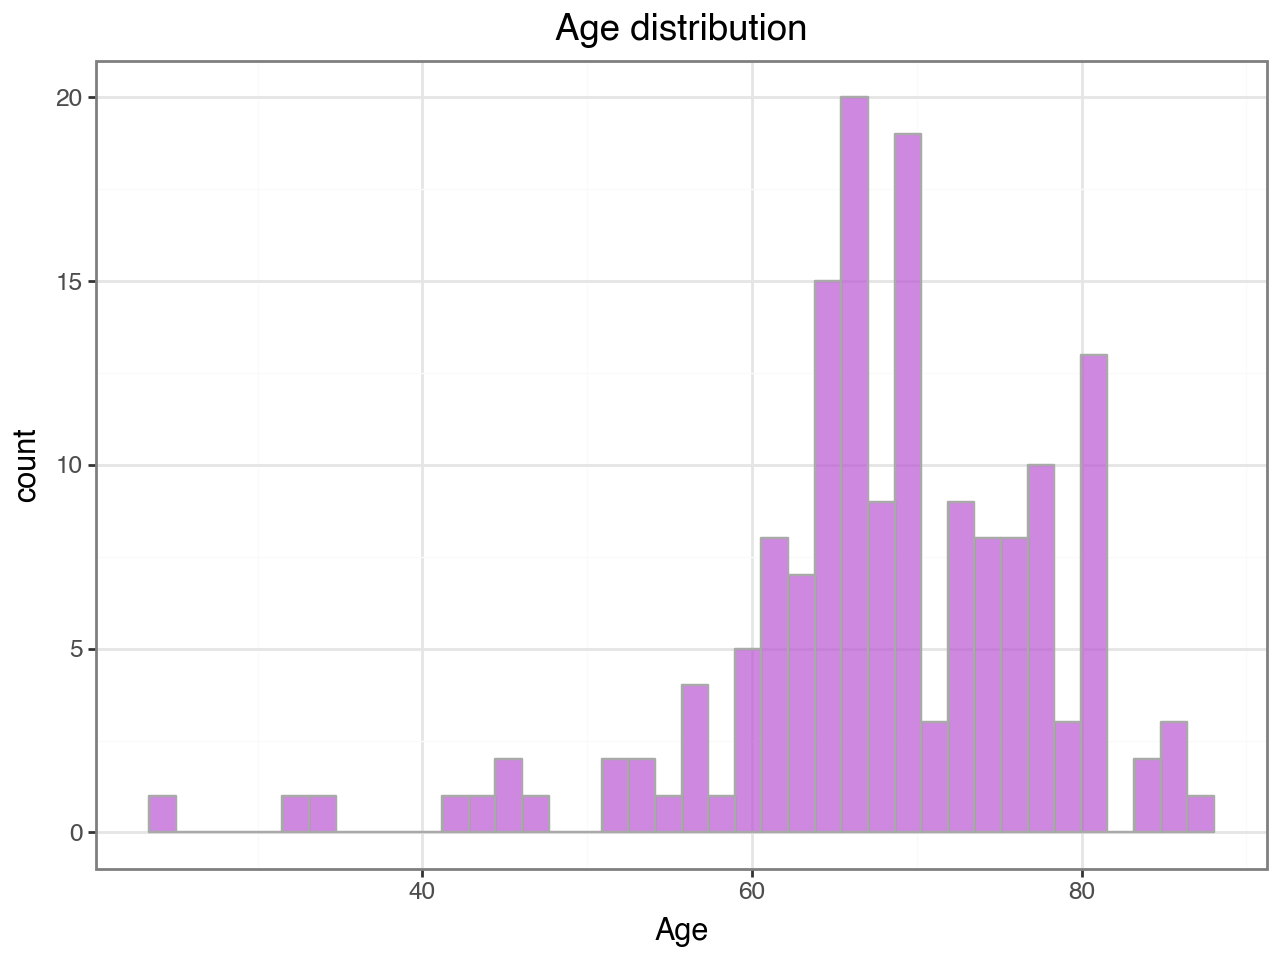

In [7]:
(

    ggplot(df) +
    aes(x='Age_at_Histological_Diagnosis') +
    geom_histogram(fill='mediumorchid', color='darkgray', alpha=0.7, bins=40)+
    theme_bw()+
    labs(title='Age distribution', x='Age')
)

In [8]:
## Variable target
Counter(df['EGFR_mutation_status_Mutant'])

Counter({0: 120, 1: 41})

In [9]:
### Is mutation prevalence different between men and women?
female_mutant = df[df.Gender_Female == 1]['EGFR_mutation_status_Mutant']
male_mutant = df[df.Gender_Female == 0]['EGFR_mutation_status_Mutant']

print("Mutation count in women: ", Counter(female_mutant))
print("Mutation count in men: ", Counter(male_mutant))


Mutation count in women:  Counter({0: 35, 1: 23})
Mutation count in men:  Counter({0: 85, 1: 18})


In [10]:
### Hypothesis test
### H0: mutation prevalence in men = mutation prevalence in women
### H1: mutation prevalence in men < mutation prevalence in women
### Alpha= 0.05

### Statistical test for categorical variables:

# Example: association between Sex and Outcome
table = pd.crosstab(df['Gender_Female'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table)

print("Contingency table:")
print(table)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)


Contingency table:
EGFR_mutation_status_Mutant   0   1
Gender_Female                      
0                            85  18
1                            35  23

Chi2: 8.483701059945401
p-value: 0.003583423417513623
Degrees of freedom: 1
Expected frequencies:
[[76.77018634 26.22981366]
 [43.22981366 14.77018634]]


In [11]:
### Age and EGFR mutation

age_mutant = df[df['EGFR_mutation_status_Mutant'] == 1]['Age_at_Histological_Diagnosis']
age_wildtype = df[df['EGFR_mutation_status_Mutant'] == 0]['Age_at_Histological_Diagnosis']

print("Median age in patients with EGFR mutation: ", age_mutant.median())
print("Median age in patients without EGFR mutation: ", age_wildtype.median())

Median age in patients with EGFR mutation:  68.0
Median age in patients without EGFR mutation:  69.0


In [12]:
### Are patients with EGFR mutation younger than those without EGFR mutation?
### H0: age in EGFR-mutated patients = age in non-mutated EGFR patients
### H1: age in EGFR-mutated patients != age in non-mutated EGFR patients
### Alpha= 0.05

U1, p = mannwhitneyu(age_mutant,age_wildtype, alternative='two-sided')
print(f"U statistic: {U1}")
print(f"p-value: {p}")

U statistic: 2406.0
p-value: 0.8353978379160674


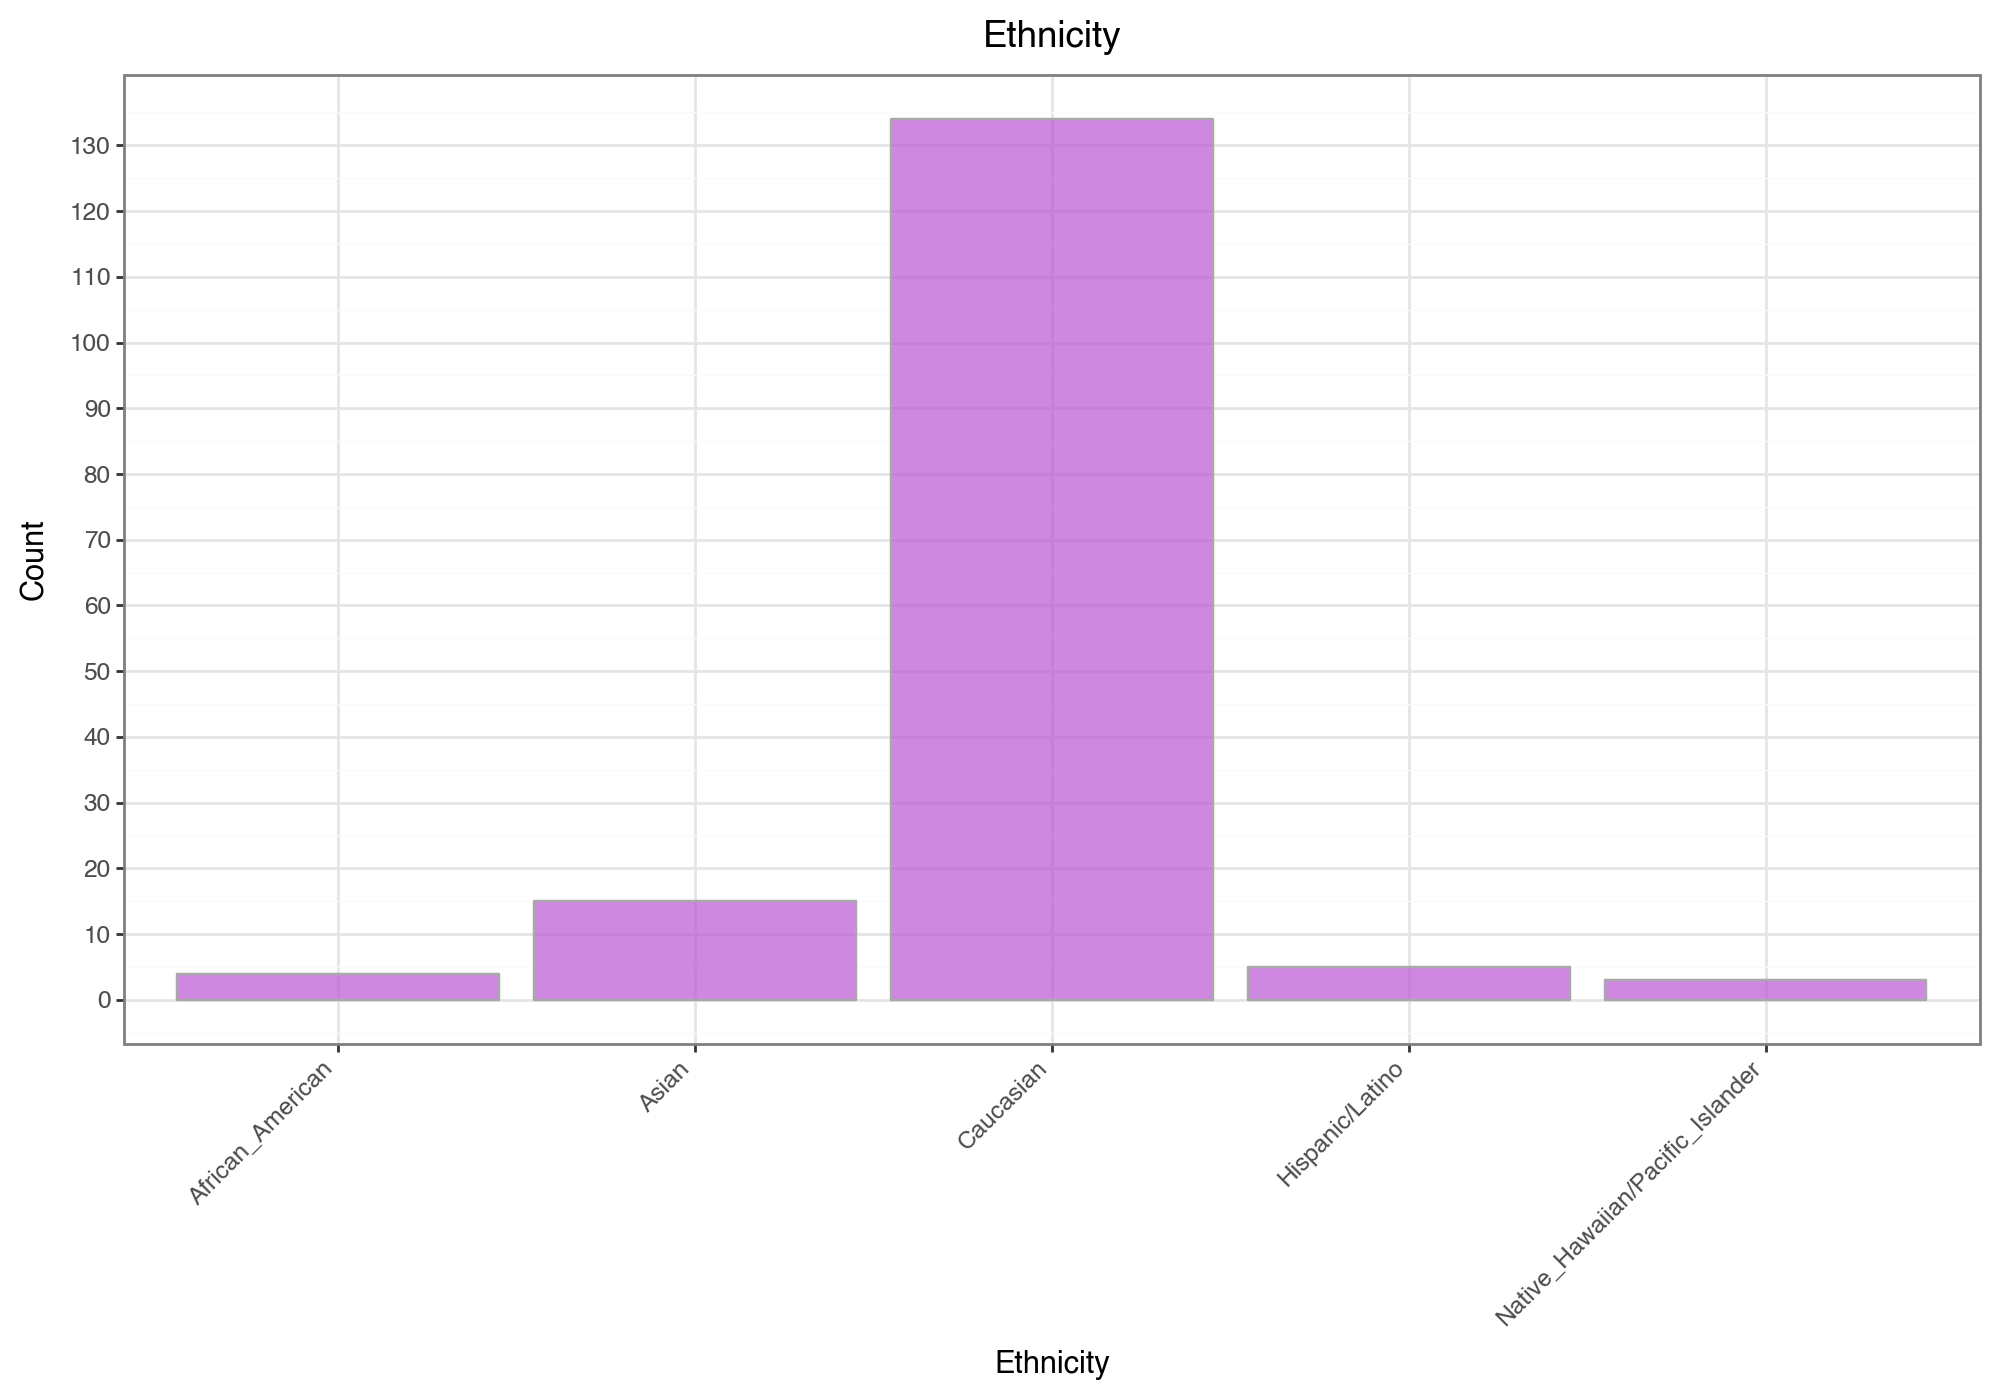

In [13]:
# One-hot ethnicity columns
ethnicity_columns = [
    'Ethnicity_Caucasian',
    'Ethnicity_Native_Hawaiian/Pacific_Islander',
    'Ethnicity_African_American',
    'Ethnicity_Asian',
    'Ethnicity_Hispanic/Latino'
]

# Sum each column to obtain the absolute frequency
counts = df[ethnicity_columns].sum().reset_index()
counts.columns = ['Ethnicity', 'Count']

# Clean names for better display in the plot
counts['Ethnicity'] = counts['Ethnicity'].str.replace('Ethnicity_', '', regex=False)

# Bar plot
plot = (
    ggplot(counts, aes(x='Ethnicity', y='Count'))
    + geom_col(fill='mediumorchid', alpha=0.7, color='darkgray')
    + theme_bw()
    + labs(
        title='Ethnicity',
        x='Ethnicity',
        y='Count'
    )
    + theme(
        axis_text_x=element_text(rotation=45, ha='right'),
        figure_size=(10, 7)
    )+

        scale_y_continuous(breaks=list(range(0,135,10)))
)

plot

In [14]:
### Does EGFR mutation prevalence differ by ethnicity?
### First, a binary question: difference between Caucasian versus non-Caucasian patients

### H0: EGFR mutation prevalence in Caucasian patients = prevalence in non-Caucasian patients.
### H1: EGFR mutation prevalence in Caucasian patients != prevalence in non-Caucasian patients.
### Alpha= 0.05

table2 = pd.crosstab(df['Ethnicity_Caucasian'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table2)

print("Contingency table:")
print(table2)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Contingency table:
EGFR_mutation_status_Mutant    0   1
Ethnicity_Caucasian                 
0                             17  10
1                            103  31

Chi2: 1.6145282086630985
p-value: 0.20385644188543192
Degrees of freedom: 1
Expected frequencies:
[[20.1242236  6.8757764]
 [99.8757764 34.1242236]]


In [15]:
### And in the case of Asian patients?

table3 = pd.crosstab(df['Ethnicity_Asian'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table3)

print("Contingency table:")
print(table3)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Contingency table:
EGFR_mutation_status_Mutant    0   1
Ethnicity_Asian                     
0                            114  32
1                              6   9

Chi2: 8.483658374169359
p-value: 0.003583507497662396
Degrees of freedom: 1
Expected frequencies:
[[108.81987578  37.18012422]
 [ 11.18012422   3.81987578]]


In [16]:
### Tabaco
table4 = pd.crosstab(df['Smoking_status_Nonsmoker'], df['EGFR_mutation_status_Mutant'])

chi2_stat, p_value, dof, expected = chi2_contingency(table4)

print("Contingency table:")
print(table4)
print("\nChi2:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Contingency table:
EGFR_mutation_status_Mutant    0   1
Smoking_status_Nonsmoker            
0                            103  20
1                             17  21

Chi2: 21.257766812865498
p-value: 4.014802796818601e-06
Degrees of freedom: 1
Expected frequencies:
[[91.67701863 31.32298137]
 [28.32298137  9.67701863]]


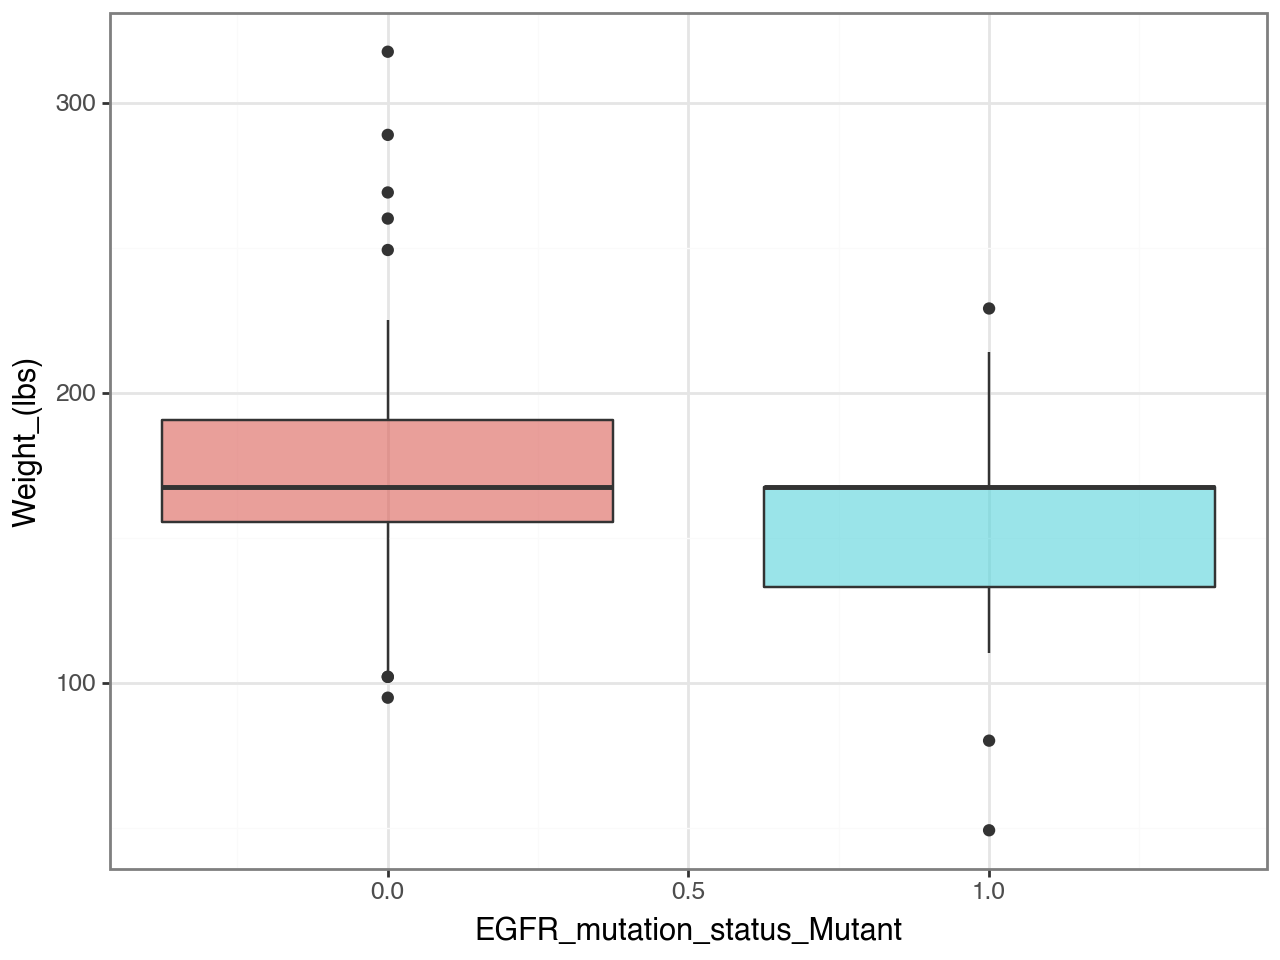

In [17]:
### Weight

(
ggplot(df)+
    aes(x='EGFR_mutation_status_Mutant', y='Weight_(lbs)', fill='factor(EGFR_mutation_status_Mutant)')+
    geom_boxplot(alpha=0.6, show_legend=False)+
    theme_bw()

)

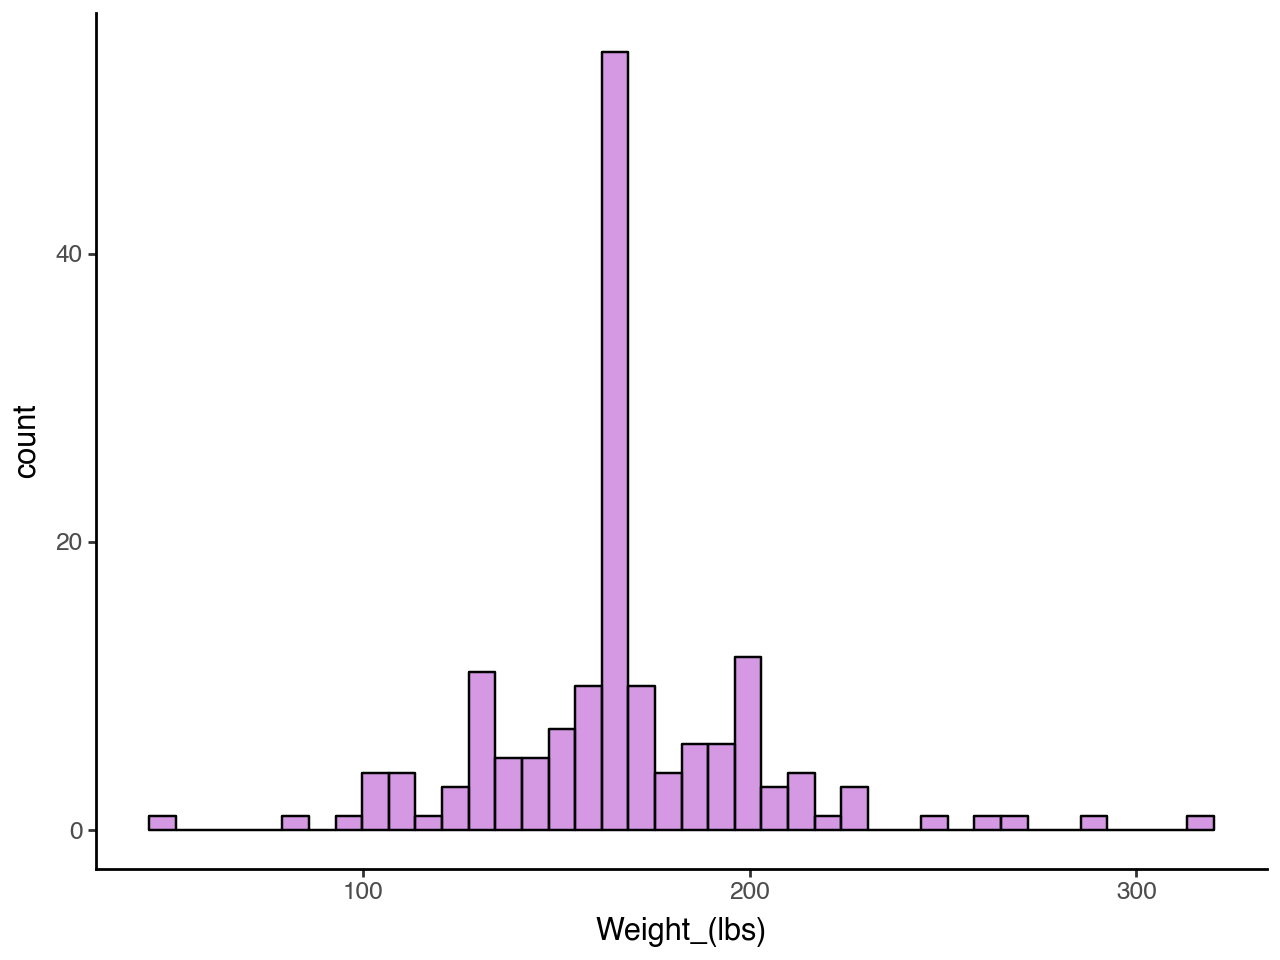

In [18]:
(
    ggplot(df) +
    aes(x='Weight_(lbs)')+
    geom_histogram(fill='mediumorchid', color='black', alpha=0.6, bins=40) +
    theme_classic()
)

In [19]:
### Normally distributed data?
from scipy.stats import shapiro

stat, p_value = shapiro(df['Weight_(lbs)'])

print("W statistic =", stat)
print("p-value =", p_value)

if p_value > 0.05:
    print("Normality is not rejected")
else:
    print("Normality is rejected")

W statistic = 0.9249574311090945
p-value = 1.9992749530461688e-07
Normality is rejected


In [20]:
### Non-parametric test:

weight_mutant = df[df['EGFR_mutation_status_Mutant'] == 1]['Weight_(lbs)']
weight_wildtype = df[df['EGFR_mutation_status_Mutant'] == 0]['Weight_(lbs)']

print("Mean weight in EGFR-mutated patients:", weight_mutant.mean())
print("Mean weight in EGFR wild-type patients:", weight_wildtype.mean())

U1, p = mannwhitneyu(weight_mutant,weight_wildtype, alternative='two-sided')
print(f"U statistic: {U1}")
print(f"p-value: {p}")

Mean weight in EGFR-mutated patients: 155.4886743902439
Mean weight in EGFR wild-type patients: 171.78005833333336
U statistic: 1873.5
p-value: 0.020578731259632214


### Radiomics features

In [21]:
radiomics_class = []
features_class_dictionay = dict()

for var in df.columns[13:]:
    feature_type = var.split('_')[1]

    if feature_type not in features_class_dictionay:
        features_class_dictionay[feature_type] = []

    features_class_dictionay[feature_type].append(var)
    radiomics_class.append(feature_type)

Counter(radiomics_class)

Counter({'firstorder': 18,
         'glrlm': 16,
         'glszm': 16,
         'gldm': 14,
         'shape': 14,
         'glcm': 4})

In [22]:
matrix = df.loc[:,features_class_dictionay['firstorder']].copy()
matrix

,original_firstorder_Uniformity,original_firstorder_Entropy,original_firstorder_Variance,original_firstorder_TotalEnergy,original_firstorder_Skewness,original_firstorder_RootMeanSquared,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_Range,original_firstorder_Minimum,original_firstorder_Median,original_firstorder_Mean,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Maximum,original_firstorder_Kurtosis,original_firstorder_InterquartileRange,original_firstorder_Energy,original_firstorder_90Percentile,original_firstorder_10Percentile
0,0.999444,3.684123e-03,0.003603,38270.647202,-3.066997,0.941481,0.020933,2.785557,-0.651340,0.938675,0.939566,0.036125,2.134217,87.708866,0.049080,38270.647202,0.994608,0.888671
1,1.000000,-3.203427e-16,0.001775,31408.801280,-1.572050,1.011099,0.013149,1.304242,0.318233,1.010996,1.010221,0.024511,1.622475,30.427388,0.030448,31408.801280,1.046498,0.975335
2,0.999920,6.400421e-04,0.015975,25904.534052,0.001753,1.016143,0.053255,2.970151,-0.164051,1.010018,1.008252,0.088131,2.806099,10.387765,0.124495,25904.534052,1.147628,0.869108
3,1.000000,-3.203427e-16,0.003324,72624.394869,-0.488388,1.183291,0.022265,1.538356,0.519116,1.182013,1.181886,0.038230,2.057472,15.511916,0.051536,72624.394869,1.241714,1.123065
4,1.000000,-3.203427e-16,0.002097,69674.204172,-1.210988,0.992951,0.015972,1.536238,0.223623,0.992003,0.991894,0.028130,1.759860,30.979075,0.037158,69674.204172,1.034957,0.950464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,0.999428,3.780866e-03,0.003794,30258.649445,-2.410015,0.849417,0.022428,2.348646,-0.784758,0.846391,0.847181,0.038289,1.563889,70.222150,0.052652,30258.649445,0.905374,0.790358
157,0.999853,1.115436e-03,0.019239,76180.774545,0.005979,1.183203,0.064004,3.581723,-0.298489,1.173773,1.175045,0.100002,3.283234,10.814940,0.152277,76180.774545,1.331208,1.021301
158,0.999769,1.678090e-03,0.003111,46661.798542,-3.072270,0.877668,0.020135,2.501164,-0.871671,0.876439,0.875894,0.034110,1.629493,97.715112,0.047389,46661.798542,0.926498,0.825272
159,0.999204,5.069631e-03,0.012320,50766.271259,-0.706682,1.090216,0.038162,3.464965,-0.275679,1.083670,1.084551,0.067789,3.189286,28.756976,0.088633,50766.271259,1.187784,0.986113


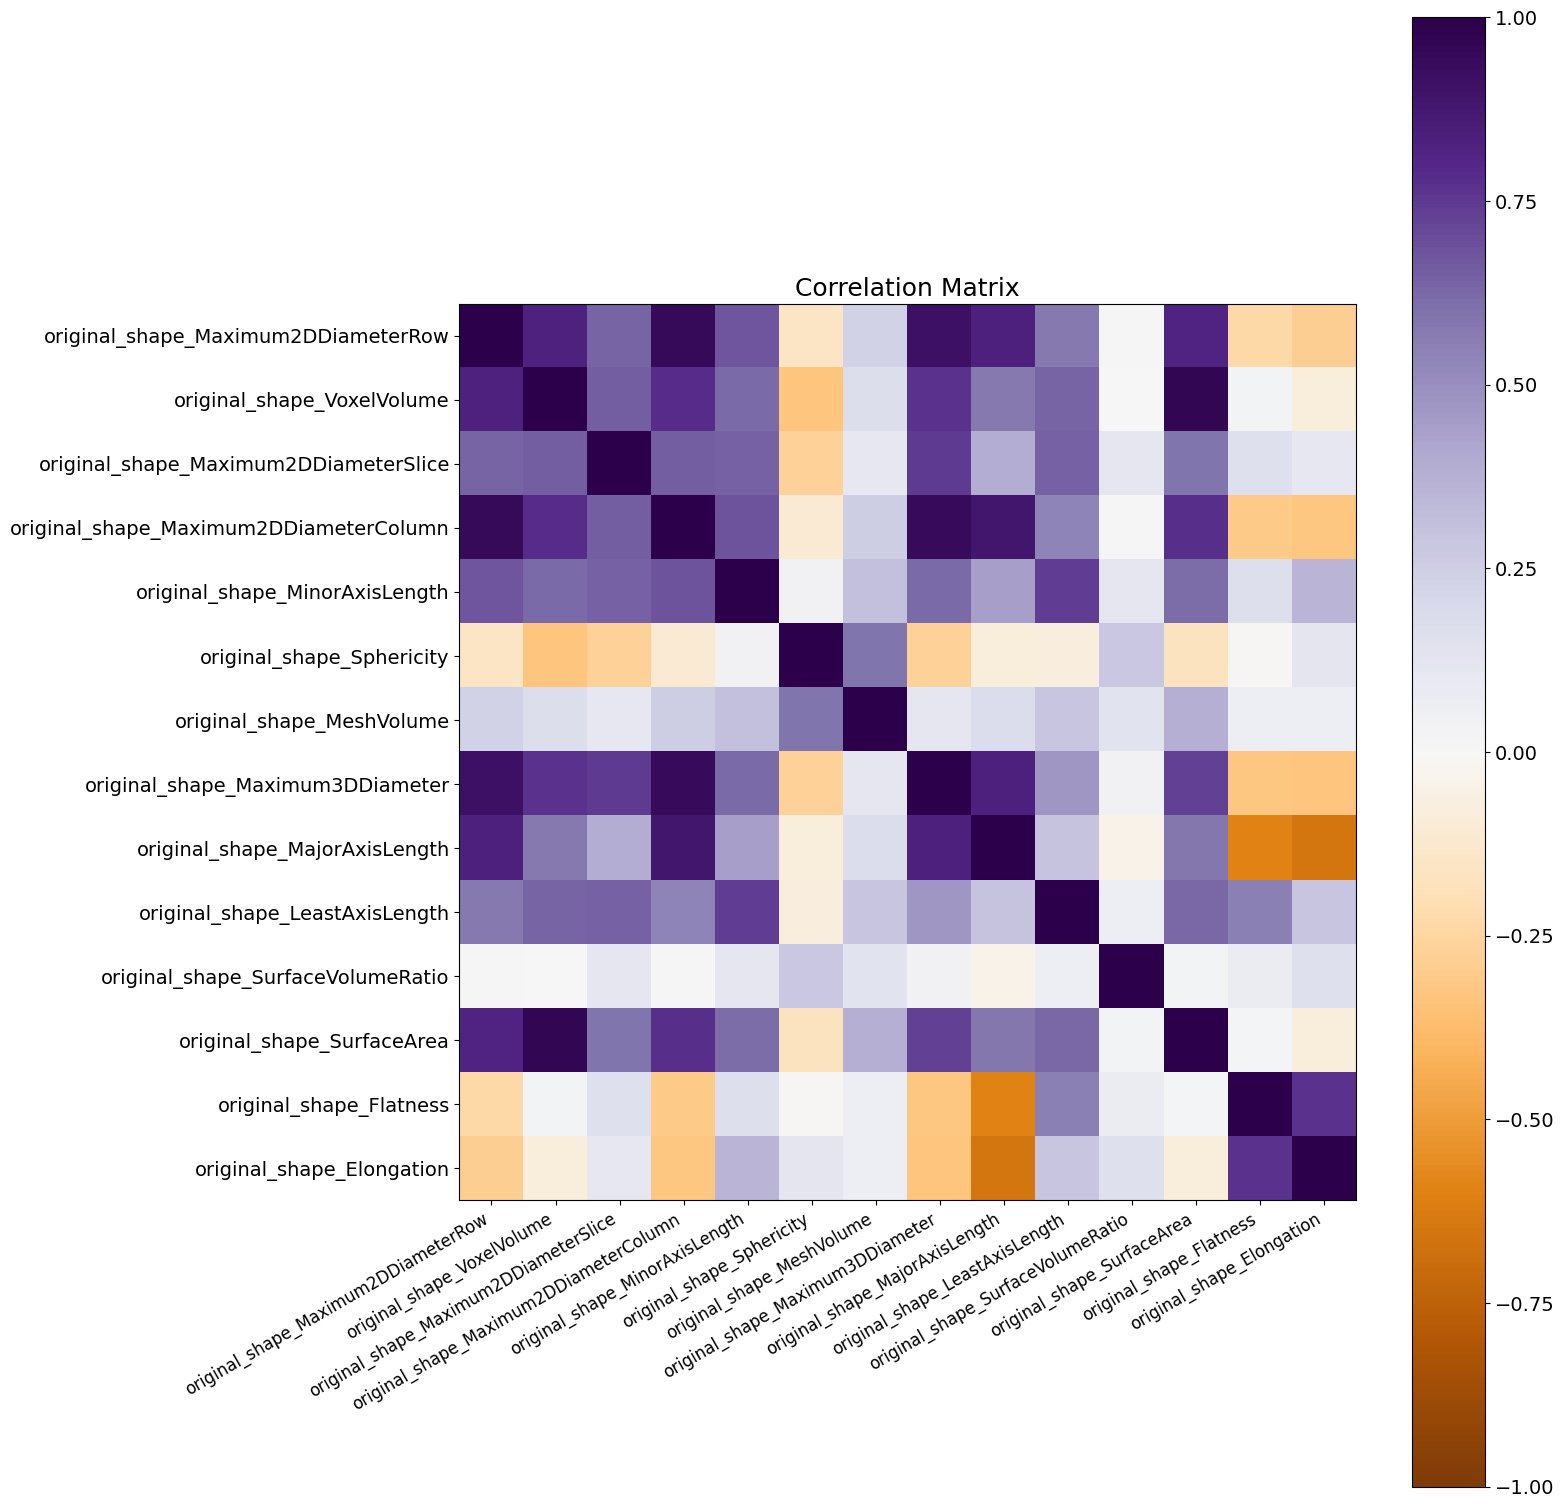

In [23]:

# Select numerical variables
corr_df = df.loc[:, features_class_dictionay['shape']].select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot
fig, ax = plt.subplots(figsize=(16,16))

im = ax.imshow(corr_matrix, cmap='PuOr', vmin=-1, vmax=1)

# Ticks and labels
ax.set_xticks(range(corr_matrix.shape[1]))
ax.set_yticks(range(corr_matrix.shape[0]))
ax.set_xticklabels(corr_matrix.columns, fontsize=12, rotation=30, ha='right')
ax.set_yticklabels(corr_matrix.columns, fontsize=14)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=14)

ax.set_title('Correlation Matrix', fontsize=18)

plt.tight_layout()
plt.show()

## Models univariados

In [24]:
df.columns[0:30]

Index(['Gender_Female', 'Ethnicity_Caucasian',
       'Ethnicity_Native_Hawaiian/Pacific_Islander',
       'Ethnicity_African_American', 'Ethnicity_Asian',
       'Ethnicity_Hispanic/Latino', 'Smoking_status_Nonsmoker',
       'Histology_Adenocarcinoma', 'Histology_Squamous_cell_carcinoma',
       'Histology_NSCLC_NOS_(not_otherwise_specified)',
       'EGFR_mutation_status_Mutant', 'Age_at_Histological_Diagnosis',
       'Weight_(lbs)', 'original_glcm_MCC', 'original_glcm_JointAverage',
       'original_glrlm_GrayLevelNonUniformityNormalized',
       'original_glrlm_GrayLevelVariance',
       'original_glrlm_HighGrayLevelRunEmphasis',
       'original_glrlm_LowGrayLevelRunEmphasis',
       'original_glszm_GrayLevelNonUniformityNormalized',
       'original_glszm_GrayLevelVariance',
       'original_glszm_HighGrayLevelZoneEmphasis',
       'original_glszm_LowGrayLevelZoneEmphasis',
       'original_gldm_GrayLevelVariance',
       'original_gldm_HighGrayLevelEmphasis',
       'original_

In [25]:
df_xy = df.drop(columns=['Histology_Adenocarcinoma', 'Histology_Squamous_cell_carcinoma',
       'Histology_NSCLC_NOS_(not_otherwise_specified)','EGFR_mutation_status_Mutant'])

df_xy.insert(loc=0,
            column='EGFR_mutation_status_Mutant',
            value=df.EGFR_mutation_status_Mutant)

df_xy.head(3)

,EGFR_mutation_status_Mutant,Gender_Female,Ethnicity_Caucasian,Ethnicity_Native_Hawaiian/Pacific_Islander,Ethnicity_African_American,Ethnicity_Asian,Ethnicity_Hispanic/Latino,Smoking_status_Nonsmoker,Age_at_Histological_Diagnosis,Weight_(lbs),...,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_shape_Elongation
0,0,0,1,0,0,0,0,1,34,167.58,...,0.102842,41018.867924,0.963427,0.980628,0.018740,0.982570,3.929464,0.245847,32771.004941,0.960259
1,0,1,1,0,0,0,0,1,33,167.58,...,0.061278,30075.092220,0.985918,0.992892,0.007244,0.994672,0.994672,0.994672,27995.000000,0.890167
2,1,1,1,0,0,0,0,1,69,167.58,...,0.029984,24864.305876,0.994052,0.997014,0.003011,0.997761,3.990923,0.249470,24127.000083,0.953047


In [26]:
import statsmodels.api as sm

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import roc_auc_score


def univariate_logistic_repeated_auc_scaled(
    df,
    target_col,
    feature_cols,
    n_splits=30,
    test_size=0.30,
    random_state=42,
    scaler_method='standard',
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
):
    """
    Iterative evaluation of univariate logistic regression for multiple variables
    using StratifiedShuffleSplit, scaling fitted only on the training set, and AUC on the test set.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with target and predictors.
    target_col : str
        Name of the binary target variable (0/1).
    feature_cols : list
        List of numerical predictor variables to evaluate.
    n_splits : int
        Number of repeated splits.
    test_size : float
        Proportion of the test set.
    random_state : int
        Seed for reproducibility.
    scaler_method : str
        'standard', 'minmax', or 'robust'.
    min_train_n : int
        Minimum number of observations required in the training set.
    min_test_n : int
        Minimum number of observations required in the test set.
    dropna : bool
        If True, removes NA values in each split and for each variable.
    verbose : bool
        If True, prints errors.

    Returns
    -------
    results_df : pd.DataFrame
        Summary per variable.
    """

    # Scaler selection
    if scaler_method == 'standard':
        scaler_class = StandardScaler
    elif scaler_method == 'minmax':
        scaler_class = MinMaxScaler
    elif scaler_method == 'robust':
        scaler_class = RobustScaler
    else:
        raise ValueError("scaler_method must be 'standard', 'minmax', or 'robust'")

    y_global = df[target_col].values

    splitter = StratifiedShuffleSplit(
        n_splits=n_splits,
        test_size=test_size,
        random_state=random_state
    )

    results = []

    for feature in feature_cols:
        aucs = []
        betas = []
        ors = []
        pvals = []
        ci_lows = []
        ci_highs = []

        n_train_list = []
        n_test_list = []

        failed_splits = 0

        for split_number, (train_idx, test_idx) in enumerate(splitter.split(df, y_global), start=1):
            try:
                data_train = df.iloc[train_idx][[target_col, feature]].copy()
                data_test = df.iloc[test_idx][[target_col, feature]].copy()

                if dropna:
                    data_train = data_train.dropna()
                    data_test = data_test.dropna()

                n_train = len(data_train)
                n_test = len(data_test)

                n_train_list.append(n_train)
                n_test_list.append(n_test)

                # Minimum checks
                if n_train < min_train_n or n_test < min_test_n:
                    failed_splits += 1
                    continue

                # Verify binary target in both splits
                if data_train[target_col].nunique() != 2:
                    failed_splits += 1
                    continue

                if data_test[target_col].nunique() != 2:
                    failed_splits += 1
                    continue

                # Verify predictor variability
                if data_train[feature].nunique() < 2:
                    failed_splits += 1
                    continue

                # Scaling fitted only on the training set
                scaler = scaler_class()

                X_train_raw = data_train[[feature]].astype(float)
                X_test_raw = data_test[[feature]].astype(float)

                X_train_scaled = scaler.fit_transform(X_train_raw)
                X_test_scaled = scaler.transform(X_test_raw)

                X_train_scaled = pd.DataFrame(
                    X_train_scaled,
                    columns=[feature],
                    index=data_train.index
                )
                X_test_scaled = pd.DataFrame(
                    X_test_scaled,
                    columns=[feature],
                    index=data_test.index
                )

                y_train = data_train[target_col]
                y_test = data_test[target_col]

                # Logistic fitting
                X_train_model = sm.add_constant(X_train_scaled)
                fit = sm.Logit(y_train, X_train_model).fit(method='lbfgs',
                                                           maxiter=200,disp=0,warn_convergence=False)


                # Verify actual convergence
                if not getattr(fit, 'mle_retvals', {}).get('converged', True):
                    raise RuntimeError('model_not_converged')


                beta = fit.params[feature]
                p_value = fit.pvalues[feature]
                ci_low, ci_high = fit.conf_int().loc[feature]

                # Prediction on the test set
                X_test_model = sm.add_constant(X_test_scaled, has_constant='add')
                y_prob_test = fit.predict(X_test_model)
                auc_test = roc_auc_score(y_test, y_prob_test)

                aucs.append(auc_test)
                betas.append(beta)
                ors.append(np.exp(beta))
                pvals.append(p_value)
                ci_lows.append(np.exp(ci_low))
                ci_highs.append(np.exp(ci_high))

            except Exception as e:
                failed_splits += 1
                if verbose:
                    print(f'Error in feature {feature}, split {split_number}: {e}')
                continue

        successful_splits = len(aucs)

        if successful_splits == 0:
            results.append({
                'feature': feature,
                'mean_AUC_test': np.nan,
                'std_AUC_test': np.nan,
                'median_AUC_test': np.nan,
                'mean_beta_train': np.nan,
                'mean_OR_train': np.nan,
                'median_p_value_train': np.nan,
                'mean_CI95_low_train': np.nan,
                'mean_CI95_high_train': np.nan,
                'mean_n_train': np.nan if len(n_train_list) == 0 else np.mean(n_train_list),
                'mean_n_test': np.nan if len(n_test_list) == 0 else np.mean(n_test_list),
                'successful_splits': 0,
                'failed_splits': failed_splits,
                'scaler': scaler_method,
                'status': 'no_valid_fit'
            })
        else:
            results.append({
                'feature': feature,
                'mean_AUC_test': np.mean(aucs),
                'std_AUC_test': np.std(aucs),
                'median_AUC_test': np.median(aucs),
                'mean_beta_train': np.mean(betas),
                'mean_OR_train': np.mean(ors),
                'median_p_value_train': np.median(pvals),
                'mean_CI95_low_train': np.mean(ci_lows),
                'mean_CI95_high_train': np.mean(ci_highs),
                'mean_n_train': np.mean(n_train_list) if len(n_train_list) > 0 else np.nan,
                'mean_n_test': np.mean(n_test_list) if len(n_test_list) > 0 else np.nan,
                'successful_splits': successful_splits,
                'failed_splits': failed_splits,
                'scaler': scaler_method,
                'status': 'ok'
            })

    results_df = pd.DataFrame(results).sort_values(
        by=['mean_AUC_test', 'median_p_value_train'],
        ascending=[False, True],
        na_position='last'
    ).reset_index(drop=True)

    return results_df

In [27]:
target_col = 'EGFR_mutation_status_Mutant'

results_repeated_scaled = univariate_logistic_repeated_auc_scaled(
    df=df_xy,
    target_col=target_col,
    feature_cols=df_xy.columns[1:],
    n_splits=100, ## Repeticiones
    test_size=0.30,
    random_state=42,
    scaler_method='standard',   # 'standard', 'minmax' o 'robust'
    min_train_n=20,
    min_test_n=10,
    dropna=True,
    verbose=False
)

results_repeated_scaled.head(20)

,feature,mean_AUC_test,std_AUC_test,median_AUC_test,mean_beta_train,mean_OR_train,median_p_value_train,mean_CI95_low_train,mean_CI95_high_train,mean_n_train,mean_n_test,successful_splits,failed_splits,scaler,status
0,original_gldm_GrayLevelNonUniformity,0.713964,0.077355,0.717342,-0.940285,0.400775,0.003813,0.216957,0.743254,112.0,49.0,100,0,standard,ok
1,original_shape_VoxelVolume,0.713705,0.077353,0.716779,-0.940413,0.400723,0.003808,0.216926,0.743172,112.0,49.0,100,0,standard,ok
2,original_glrlm_GrayLevelNonUniformity,0.713423,0.077742,0.718468,-0.935549,0.402761,0.004019,0.217695,0.748154,112.0,49.0,100,0,standard,ok
3,original_shape_SurfaceArea,0.711104,0.078200,0.712838,-0.926009,0.405666,0.003331,0.222795,0.741162,112.0,49.0,100,0,standard,ok
4,original_glrlm_RunLengthNonUniformity,0.711036,0.077214,0.712838,-0.922741,0.407719,0.004344,0.220892,0.755561,112.0,49.0,100,0,standard,ok
5,original_shape_Maximum2DDiameterColumn,0.692162,0.075844,0.689189,-0.748542,0.479411,0.005575,0.281864,0.817019,112.0,49.0,100,0,standard,ok
6,Smoking_status_Nonsmoker,0.687230,0.066963,0.682432,0.787734,2.213807,0.000144,1.470620,3.332903,112.0,49.0,100,0,standard,ok
7,original_firstorder_TotalEnergy,0.684572,0.075478,0.682432,-0.772446,0.469769,0.009449,0.266045,0.831641,112.0,49.0,100,0,standard,ok
8,original_firstorder_Energy,0.684572,0.075478,0.682432,-0.772446,0.469769,0.009449,0.266045,0.831641,112.0,49.0,100,0,standard,ok
9,original_shape_LeastAxisLength,0.682613,0.088197,0.694820,-0.610850,0.549777,0.015194,0.345600,0.875092,112.0,49.0,100,0,standard,ok


In [28]:
threshold = .05

features_univariate_filter = results_repeated_scaled[results_repeated_scaled.median_p_value_train < threshold].feature.to_list()

print("Number of significant variables:", results_repeated_scaled[results_repeated_scaled.median_p_value_train < threshold].shape[0])
print("Variables:\n\n",features_univariate_filter)


Number of significant variables: 16
Variables:

 ['original_gldm_GrayLevelNonUniformity', 'original_shape_VoxelVolume', 'original_glrlm_GrayLevelNonUniformity', 'original_shape_SurfaceArea', 'original_glrlm_RunLengthNonUniformity', 'original_shape_Maximum2DDiameterColumn', 'Smoking_status_Nonsmoker', 'original_firstorder_TotalEnergy', 'original_firstorder_Energy', 'original_shape_LeastAxisLength', 'original_shape_Maximum2DDiameterRow', 'original_glszm_GrayLevelNonUniformity', 'original_shape_Maximum2DDiameterSlice', 'Gender_Female', 'Weight_(lbs)', 'Ethnicity_Asian']


In [29]:
results_repeated_scaled.sort_values(by=["mean_AUC_test"], ascending=False).head(30)

,feature,mean_AUC_test,std_AUC_test,median_AUC_test,mean_beta_train,mean_OR_train,median_p_value_train,mean_CI95_low_train,mean_CI95_high_train,mean_n_train,mean_n_test,successful_splits,failed_splits,scaler,status
0,original_gldm_GrayLevelNonUniformity,0.713964,0.077355,0.717342,-0.940285,0.400775,0.003813,0.216957,0.743254,112.0,49.0,100,0,standard,ok
1,original_shape_VoxelVolume,0.713705,0.077353,0.716779,-0.940413,0.400723,0.003808,0.216926,0.743172,112.0,49.0,100,0,standard,ok
2,original_glrlm_GrayLevelNonUniformity,0.713423,0.077742,0.718468,-0.935549,0.402761,0.004019,0.217695,0.748154,112.0,49.0,100,0,standard,ok
3,original_shape_SurfaceArea,0.711104,0.078200,0.712838,-0.926009,0.405666,0.003331,0.222795,0.741162,112.0,49.0,100,0,standard,ok
4,original_glrlm_RunLengthNonUniformity,0.711036,0.077214,0.712838,-0.922741,0.407719,0.004344,0.220892,0.755561,112.0,49.0,100,0,standard,ok
5,original_shape_Maximum2DDiameterColumn,0.692162,0.075844,0.689189,-0.748542,0.479411,0.005575,0.281864,0.817019,112.0,49.0,100,0,standard,ok
6,Smoking_status_Nonsmoker,0.687230,0.066963,0.682432,0.787734,2.213807,0.000144,1.470620,3.332903,112.0,49.0,100,0,standard,ok
7,original_firstorder_TotalEnergy,0.684572,0.075478,0.682432,-0.772446,0.469769,0.009449,0.266045,0.831641,112.0,49.0,100,0,standard,ok
8,original_firstorder_Energy,0.684572,0.075478,0.682432,-0.772446,0.469769,0.009449,0.266045,0.831641,112.0,49.0,100,0,standard,ok
9,original_shape_LeastAxisLength,0.682613,0.088197,0.694820,-0.610850,0.549777,0.015194,0.345600,0.875092,112.0,49.0,100,0,standard,ok


### L1-regularized regression (Lasso)

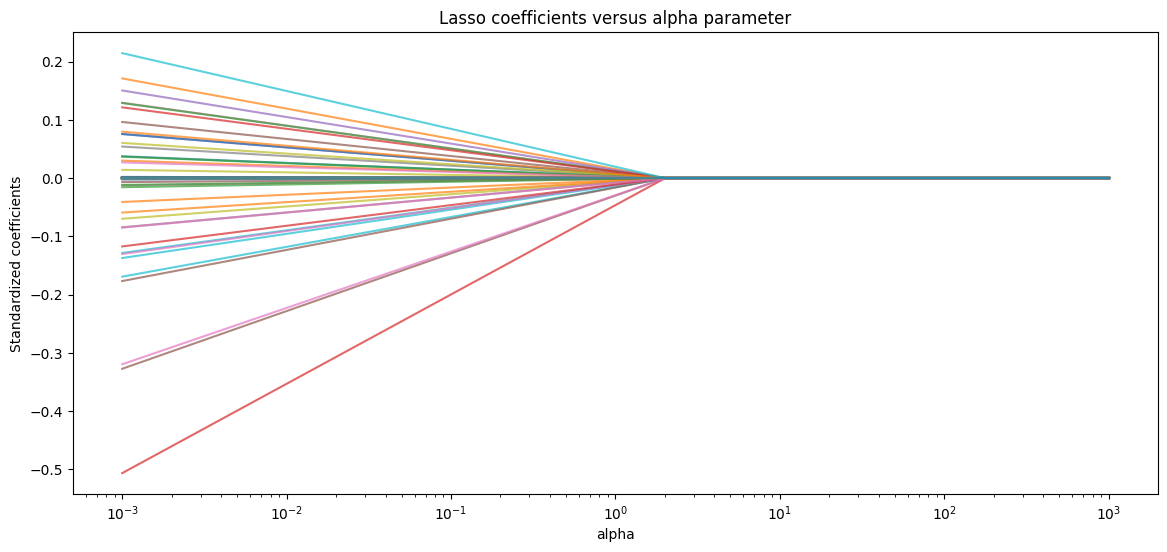

In [30]:

from sklearn.linear_model import Lasso

scaler = StandardScaler()
XRadiomicsScale = scaler.fit_transform(df_xy.iloc[:,1:])

alphas = np.linspace(0.001,1000,500)
lasso = Lasso(max_iter=10000)
coefs = []


for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(XRadiomicsScale, df_xy.iloc[:,0])
    coefs.append(lasso.coef_)

plt.figure(figsize=(14, 6))

ax = plt.gca()

ax.plot(alphas, coefs, alpha=0.7)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('Standardized coefficients')
plt.title('Lasso coefficients versus alpha parameter')
#plt.savefig('Seleccion variables parametro alpha.png', dpi=300)
plt.show()

Best C found: 0.3593813663804626


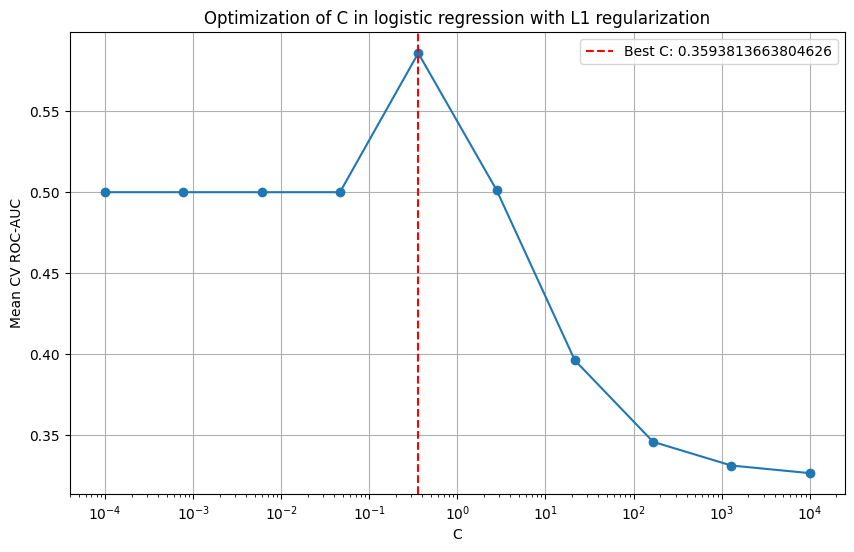

Number of selected variables: 13
Selected features:
['Gender_Female', 'Ethnicity_Asian', 'Smoking_status_Nonsmoker', 'Age_at_Histological_Diagnosis', 'Weight_(lbs)', 'original_shape_MeshVolume', 'original_shape_SurfaceArea', 'original_firstorder_TotalEnergy', 'original_firstorder_Skewness', 'original_firstorder_Minimum', 'original_firstorder_Kurtosis', 'original_shape_Flatness', 'original_firstorder_Energy']
Test AUC: 0.784


In [31]:

X = df_xy.iloc[:, 1:]
y = df_xy.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logit_l1_cv', LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 10),
        cv=cv,
        penalty='l1',
        solver='liblinear',
        scoring='roc_auc',
        random_state=0,
        max_iter=2000
    ))
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps['logit_l1_cv']

best_C = model.C_[0] if np.ndim(model.C_) else model.C_
print(f'Best C found: {best_C}')

positive_class = model.classes_[1]
mean_scores = model.scores_[positive_class].mean(axis=0)

plt.figure(figsize=(10, 6))
plt.semilogx(model.Cs_, mean_scores, marker='o')
plt.axvline(best_C, linestyle='--', color='red', label=f'Best C: {best_C}')
plt.xlabel('C')
plt.ylabel('Mean CV ROC-AUC')
plt.title('Optimization of C in logistic regression with L1 regularization')
plt.legend()
plt.grid(True)
plt.show()

coef = model.coef_[0]
selected_features_lasso = X_train.columns[coef != 0]

print("Number of selected variables:", len(selected_features_lasso))
print("Selected features:")
print(selected_features_lasso.tolist())

y_prob_test = pipeline.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)
print(f'Test AUC: {auc_test:.3f}')

### Recursive feature elimination

In [32]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# -----------------------------
# data
# -----------------------------
X = df_xy.iloc[:, 1:].copy()
y = df_xy.iloc[:, 0].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# -----------------------------
# base model
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# Sequential Forward Selection
# -----------------------------
sfs_forward = SequentialFeatureSelector(
    estimator=rf,
    n_features_to_select=10,   # you can change it to a fixed number, e.g., 10
    direction='forward',
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

sfs_forward.fit(X_train, y_train)

selected_mask = sfs_forward.get_support()
selected_features_sfs = X_train.columns[selected_mask].tolist()

print("Selected variables (forward):")
print(selected_features_sfs)

# -----------------------------
# final model with selected variables
# -----------------------------
rf_final = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_final.fit(X_train[selected_features_sfs], y_train)

y_prob_test = rf_final.predict_proba(X_test[selected_features_sfs])[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)

print(f"Test AUC: {auc_test:.3f}")

Selected variables (forward):
['Ethnicity_Caucasian', 'Ethnicity_Native_Hawaiian/Pacific_Islander', 'Ethnicity_African_American', 'Ethnicity_Asian', 'Ethnicity_Hispanic/Latino', 'Smoking_status_Nonsmoker', 'original_glszm_SizeZoneNonUniformityNormalized', 'original_glszm_ZoneEntropy', 'original_gldm_SmallDependenceEmphasis', 'original_shape_SurfaceArea']
Test AUC: 0.664


### First simple model with selected variables

In [33]:
## Selected variable sets:

## 1. Filter method:
print(f"Variables selected by filter method:{features_univariate_filter}. \n")

## 2. Lasso:
print(f"Variables selected by L1 regression (Lasso):{selected_features_lasso}. \n")

### 3. SFS
print(f"Variables selected by Recursive Feature Elimination:{selected_features_sfs}. \n")

Variables selected by filter method:['original_gldm_GrayLevelNonUniformity', 'original_shape_VoxelVolume', 'original_glrlm_GrayLevelNonUniformity', 'original_shape_SurfaceArea', 'original_glrlm_RunLengthNonUniformity', 'original_shape_Maximum2DDiameterColumn', 'Smoking_status_Nonsmoker', 'original_firstorder_TotalEnergy', 'original_firstorder_Energy', 'original_shape_LeastAxisLength', 'original_shape_Maximum2DDiameterRow', 'original_glszm_GrayLevelNonUniformity', 'original_shape_Maximum2DDiameterSlice', 'Gender_Female', 'Weight_(lbs)', 'Ethnicity_Asian']. 

Variables selected by L1 regression (Lasso):Index(['Gender_Female', 'Ethnicity_Asian', 'Smoking_status_Nonsmoker',
       'Age_at_Histological_Diagnosis', 'Weight_(lbs)',
       'original_shape_MeshVolume', 'original_shape_SurfaceArea',
       'original_firstorder_TotalEnergy', 'original_firstorder_Skewness',
       'original_firstorder_Minimum', 'original_firstorder_Kurtosis',
       'original_shape_Flatness', 'original_firstorder_

In [34]:
### Function to normalize the dataframe

def scale_dataframe(df, columns=None):
    df_scaled = df.copy()

    if columns is None:
        columns = df_scaled.select_dtypes(include='number').columns.tolist()

    scaler = StandardScaler()
    df_scaled[columns] = scaler.fit_transform(df_scaled[columns])

    return df_scaled, scaler

In [35]:
### Value scaling
df_scaled, scaler = scale_dataframe(df_xy.loc[:, selected_features_lasso],
                                      columns=selected_features_lasso)

X_train, X_test, y_train, y_test = train_test_split(df_scaled, df_xy.iloc[:, 0],
                                                    test_size=0.3, random_state=45)

model = LogisticRegression(
    penalty='l2',
    C=0.4,
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)
y_prob_test = model.predict_proba(X_test)[:, 1]
pred_test_bin = np.where(y_prob_test>0.5,1,0)

auc_test = roc_auc_score(y_test, y_prob_test)
print(classification_report(y_test, pred_test_bin))
print(f"AUC: {round(auc_test,3)} ")

              precision    recall  f1-score   support

           0       0.83      0.92      0.87        37
           1       0.62      0.42      0.50        12

    accuracy                           0.80        49
   macro avg       0.73      0.67      0.69        49
weighted avg       0.78      0.80      0.78        49

AUC: 0.759 
